In [4]:
%matplotlib ipympl
import os
# if using Apple MPS, fall back to CPU for unsupported ops
import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
import json
from tqdm import tqdm

from modules.sam_utils import *
from modules.label_csv_utils import load_keypoints



In [ ]:
from sam2.build_sam import build_sam2_video_predictor
device = torch.device("cuda")
sam2_checkpoint = "input/sam2_checkpoints/sam2.1_hiera_large.pt"
model_cfg = "configs/sam2.1/sam2.1_hiera_l.yaml"

predictor = build_sam2_video_predictor(model_cfg, sam2_checkpoint, device=device)

In [ ]:
video_name = "RAT 11 FR1 10-03-25"
video_dir = f"output/video_frames_for_sam/{video_name}"

# scan all the JPEG frame names in this directory
frame_names = [
    p for p in os.listdir(video_dir)
    if os.path.splitext(p)[-1] in [".jpg", ".jpeg", ".JPG", ".JPEG"]
]
frame_names.sort(key=lambda p: int(os.path.splitext(p)[0]))
frame_indices = [int(os.path.splitext(p)[0]) for p in frame_names]

print(f"Found {len(frame_names)} frames in {video_dir}")

Found 190 frames in video_frames/RAT 11 FR1 10-03-25


In [ ]:
csv_path = f"input/labeled-data/{video_name}/CollectedData_rats.csv"
label_df = load_keypoints(csv_path)
label_df


,frame,head_x,head_y,nose_x,nose_y,spine1_x,spine1_y,spine2_x,spine2_y,spine3_x,...,R_shoulder_x,R_shoulder_y,R_hip_x,R_hip_y,R_knee_x,R_knee_y,L_knee_x,L_knee_y,L_frontpaw_x,L_frontpaw_y
0,97,869.585376,201.143352,1125.720876,137.471250,764.671118,248.897428,654.692034,303.163423,598.255398,...,898.527241,350.917497,691.592911,536.868975,680.739712,629.482941,NaN,NaN,NaN,NaN
1,157,894.909508,377.688721,996.929579,473.196874,811.701648,321.252086,698.104830,314.016620,612.002784,...,895.633054,490.561992,702.446110,513.715484,667.715873,621.523928,NaN,NaN,927.469105,555.681187
2,179,932.547082,310.484737,NaN,NaN,866.473922,317.247891,712.930669,303.056058,602.691328,...,860.978891,444.603153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,309,NaN,NaN,NaN,NaN,NaN,NaN,825.238616,318.196413,769.927721,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,985,1002.008031,399.997481,NaN,NaN,932.780664,368.855358,809.232494,300.572503,681.725996,...,982.309616,475.839999,779.017720,491.336015,765.671021,607.455137,NaN,NaN,944.136956,590.674339
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,29083,NaN,NaN,NaN,NaN,NaN,NaN,797.348291,320.300632,786.101293,...,NaN,NaN,880.094060,475.348529,NaN,NaN,NaN,NaN,NaN,NaN
86,29336,807.791931,303.430136,NaN,NaN,695.321954,264.065644,608.559400,321.103989,582.851977,...,NaN,NaN,750.753586,454.461248,709.782380,552.470800,NaN,NaN,NaN,NaN
87,29819,NaN,NaN,NaN,NaN,NaN,NaN,696.425236,277.644907,629.676414,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
88,30144,815.022144,219.881010,851.976565,278.526069,727.456233,235.948149,652.744034,305.840207,612.576185,...,NaN,NaN,782.084508,449.641106,714.602522,542.830516,NaN,NaN,NaN,NaN


In [8]:

get_coordinates(label_df, 0)

[[869, 201],
 [1125, 137],
 [764, 248],
 [654, 303],
 [598, 411],
 [554, 536],
 [430, 549],
 [292, 552],
 [113, 652],
 [770, 485],
 [744, 583],
 [710, 672],
 [959, 371],
 [898, 350],
 [691, 536],
 [680, 629]]

In [9]:
frame_indices

[0,
 97,
 157,
 179,
 305,
 309,
 610,
 916,
 985,
 1027,
 1221,
 1526,
 1560,
 1578,
 1633,
 1693,
 1830,
 1831,
 1949,
 1960,
 2011,
 2045,
 2136,
 2434,
 2441,
 2747,
 3003,
 3052,
 3357,
 3376,
 3540,
 3662,
 3859,
 3959,
 3967,
 4272,
 4305,
 4518,
 4535,
 4578,
 4586,
 4723,
 4883,
 5050,
 5113,
 5188,
 5493,
 5754,
 5798,
 5984,
 6103,
 6387,
 6409,
 6714,
 7019,
 7324,
 7629,
 7934,
 8240,
 8317,
 8382,
 8545,
 8850,
 8873,
 9155,
 9377,
 9460,
 9625,
 9641,
 9691,
 9765,
 9776,
 9891,
 10071,
 10292,
 10376,
 10424,
 10681,
 10982,
 10986,
 11291,
 11432,
 11483,
 11530,
 11596,
 11631,
 11744,
 11902,
 11918,
 12199,
 12207,
 12512,
 12817,
 12886,
 13122,
 13312,
 13427,
 13508,
 13733,
 13811,
 14038,
 14084,
 14201,
 14343,
 14648,
 14953,
 15164,
 15258,
 15564,
 15798,
 15869,
 16160,
 16174,
 16479,
 16724,
 16784,
 17040,
 17090,
 17111,
 17395,
 17446,
 17540,
 17700,
 18005,
 18129,
 18310,
 18615,
 18644,
 18921,
 19226,
 19531,
 19779,
 19836,
 20141,
 20250,
 2044

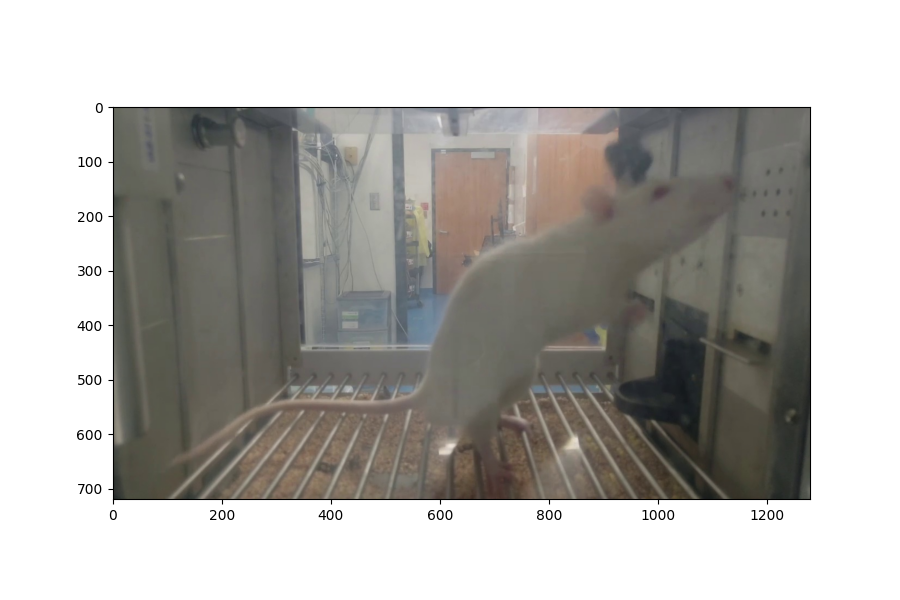

In [10]:
# show the first frame at start_idx
frame_idx = int(label_df["frame"].iloc[0])
start_idx = frame_indices.index(frame_idx)
plt.figure(figsize=(9, 6))
plt.imshow(Image.open(os.path.join(video_dir, frame_names[start_idx])))
plt.show()

In [11]:
inference_state = predictor.init_state(video_path=video_dir)

frame loading (JPEG):   0%|          | 0/190 [00:00<?, ?it/s]

frame loading (JPEG): 100%|██████████| 190/190 [00:04<00:00, 38.74it/s]


In [12]:
predictor.reset_state(inference_state)

In [13]:
# reload to update setting
n_idx = len(label_df)
ann_obj_id = 1  


label_results = []
for i in tqdm(range(n_idx)):
    ann_frame_idx = label_df["frame"].iloc[i]  
    jpg_idx = frame_indices.index(ann_frame_idx)
    
    points = get_coordinates(label_df, i)
    points = np.array(points, dtype=np.float32)
    labels = np.array([1]*len(points), np.int32)
    _, out_obj_ids, out_mask_logits = predictor.add_new_points_or_box(
        inference_state=inference_state,
        frame_idx=jpg_idx,
        obj_id=ann_obj_id,
        points=points,
        labels=labels,
    )
    label_results += [(ann_frame_idx,jpg_idx, points, labels, out_obj_ids, out_mask_logits)]


  0%|          | 0/90 [00:00<?, ?it/s]/home/jiefei/Documents/sam2/sam2/sam2_video_predictor.py:786: UserWarning: cannot import name '_C' from 'sam2' (/home/jiefei/Documents/sam2/sam2/__init__.py)

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
100%|██████████| 90/90 [00:08<00:00, 11.11it/s]


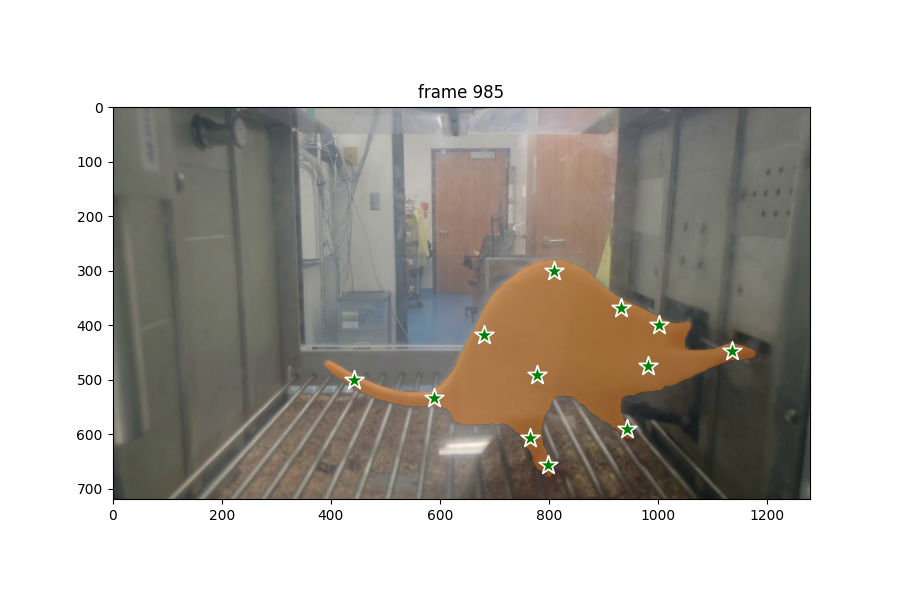

In [14]:
i = 4
ann_frame_idx,jpg_idx, points, labels, out_obj_ids, out_mask_logits = label_results[i]
plt.figure(figsize=(9, 6))
plt.title(f"frame {ann_frame_idx}")
plt.imshow(Image.open(os.path.join(video_dir, frame_names[jpg_idx])))
show_points(points, labels, plt.gca())
show_mask((out_mask_logits[0] > 0.0).cpu().numpy(), plt.gca(), obj_id=out_obj_ids[0])

In [15]:
# run propagation throughout the video and collect the results in a dict
video_segments = {}  # video_segments contains the per-frame segmentation results
for out_frame_idx, out_obj_ids, out_mask_logits in predictor.propagate_in_video(inference_state):
    video_segments[out_frame_idx] = {
        out_obj_id: (out_mask_logits[i] > 0.0).cpu().numpy()
        for i, out_obj_id in enumerate(out_obj_ids)
    }

print(f"Propagated {len(video_segments)} frames, total {len(frame_names)} frames")


propagate in video: 100%|██████████| 189/189 [00:39<00:00,  4.79it/s]

Propagated 189 frames, total 190 frames


In [16]:
len(video_segments)

189

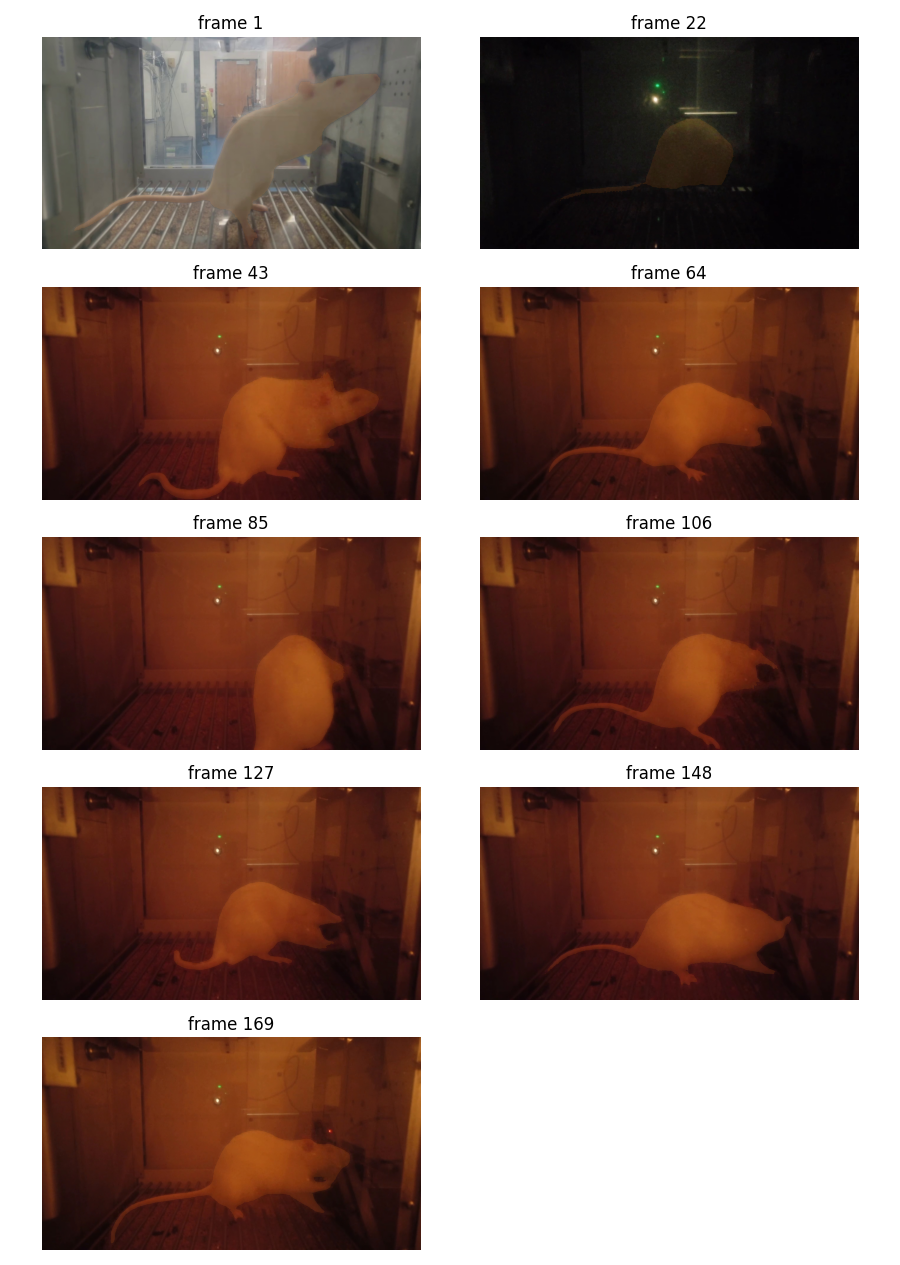

In [ ]:
# render the segmentation results in an n-by-3 grid
max_frames = 9
vis_frame_stride = len(frame_names)//max_frames
frame_choiced = list(range(1, min(max_frames * vis_frame_stride, len(frame_names)), vis_frame_stride))
ncols = 2
nrows = -(-len(frame_choiced) // ncols)  # ceil division

sample_img = Image.open(os.path.join(video_dir, frame_names[0]))
img_aspect = sample_img.size[1] / sample_img.size[0]
col_width = 9 / ncols
row_height = col_width * img_aspect

fig, axes = plt.subplots(nrows, ncols, figsize=(9, row_height * nrows))
axes = np.array(axes).reshape(-1)
for i, out_frame_idx in enumerate(frame_choiced):
    axes[i].set_title(f"frame {out_frame_idx}")
    axes[i].imshow(Image.open(os.path.join(video_dir, frame_names[out_frame_idx])))
    for out_obj_id, out_mask in video_segments[out_frame_idx].items():
        show_mask(out_mask, axes[i], obj_id=out_obj_id,transparency=0.9)
    axes[i].axis("off")
for i in range(len(frame_choiced), len(axes)):
    axes[i].axis("off")
plt.tight_layout()
plt.show()

In [21]:
video_segments.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189])

In [24]:
# save to sam2_labels/video_name.pkl
# map video_segments keys back to original frame indices
video_segments_mapped = {
    frame_indices[k]: v for k, v in video_segments.items()
}

In [26]:

import pickle
save_path = f"sam2_labels/{video_name}.pkl"
with open(save_path, "wb") as f:
    pickle.dump(video_segments_mapped, f)